In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


In [5]:
df = pd.read_pickle("../assets/data/kepler_data.pkl")


In [6]:
df.head(2)


,index,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,time,flux,flux_err,n_points
KIC,,,,,,,,,,,,,,,
3863594,0,0.053268,0.0,55000.000000,0.004327,0.79,-1.000,-1.000,-1.000,-1.0,False,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486085891724, 0.9967120885848999, 0.999...","[9.64640494203195e-05, 9.793051140150055e-05, ...",52286
10417986,1,0.073731,0.0,55000.027476,0.004231,0.99,81.039,11.082,9.128,-1.0,True,"[120.53855550513981, 120.55898988617264, 120.5...","[0.999791145324707, 0.9999734163284302, 0.9995...","[1.373476243315963e-05, 1.3659494470630307e-05...",52200


In [7]:
df.index.name


'KIC'

---

In [8]:
def plotLightCurve(df, kic, with_error=True):
    if kic not in df.index:
        raise ValueError(f"KIC {kic} not found in DataFrame index.")

    row = df.loc[kic]

    t = row["time"]
    f = row["flux"]
    e = row["flux_err"]

    plt.figure(figsize=(20, 5))

    if with_error and e is not None:
        plt.errorbar(t, f, yerr=e, fmt='-', linewidth=1)
    else:
        plt.plot(t, f, linewidth=1)

    plt.xlabel("Time")
    plt.ylabel(r"Normalized Flux (e$^{-}$ s$^{-1}$)")
    plt.title(f"KIC {kic} Light Curve")
    plt.show()
    

---

In [25]:
sampleKIC = df.sample(n = 1).index[0]
sampleKIC


np.int64(6634112)

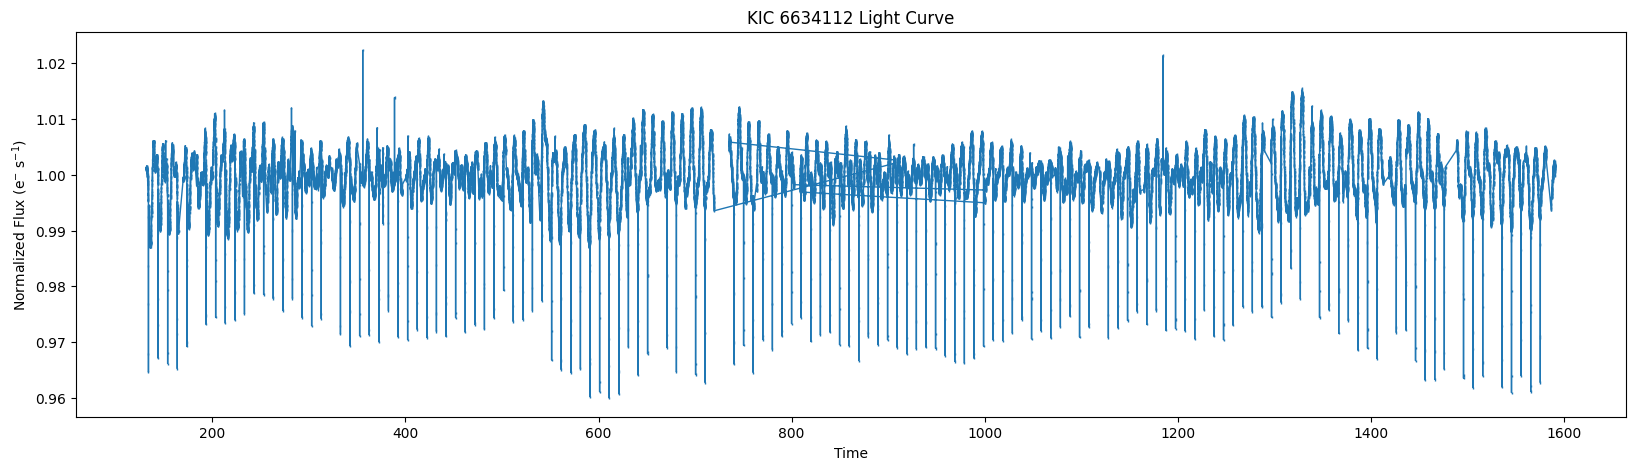

In [26]:
plotLightCurve(df, kic=sampleKIC)
